
<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# K-means Clustering


Estimated time needed: **25** minutes
    

## Objectives

After completing this lab you will be able to:

* Use scikit-learn's k-means clustering to cluster data
* Apply k-means clustering on a real world data for Customer segmentation


이 실습을 완료하면 다음을 수행할 수 있습니다.

scikit-learn의 k-평균 클러스터링을 사용하여 데이터 클러스터링
고객 세분화를 위해 실제 데이터에 k-평균 클러스터링 적용

## Introduction

**K-means** is vastly used for clustering in many data science applications. It is especially useful if you need to quickly discover insights from **unlabeled data**.

Real-world applications of k-means include:
- Customer segmentation
- Understanding what website visitors are trying to accomplish
- Pattern recognition
- Feature engineering 
- Data compression


소개
K-평균은 다양한 데이터 과학 애플리케이션에서 클러스터링에 널리 사용됩니다. 특히 레이블이 지정되지 않은 데이터에서 인사이트를 빠르게 발견해야 할 때 유용합니다.

K-평균의 실제 적용 분야는 다음과 같습니다.

고객 세분화
웹사이트 방문자의 목표 파악
패턴 인식
특징 엔지니어링
데이터 압축

### Install libraries
Ensure the required libraries are available.


In [6]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install plotly
!pip install seaborn

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


Now import the required libraries.


In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

<h1 id="random_generated_dataset">K-Means on a synthetic data set</h1>

Let's create our own dataset for this lab!
K-Means on a synthetic data set¶
Let's create our own dataset for this lab!







First, we need to set a random seed. Use numpy's random.seed() function, where the seed will be set to 0.

먼저, 난수 시드를 설정해야 합니다. numpy의 random.seed() 함수를 사용하며, 시드는 0으로 설정됩니다.


First, we need to set a random seed. Use <b>numpy's random.seed()</b> function, where the seed will be set to <b>0</b>.


In [9]:
np.random.seed(0)

Next, we will be making random clusters of points by using the `make_blobs` class. The `make_blobs` class can take in many inputs, but we will be using these specific ones. <br> <br>
<b> <u> Input </u> </b>
<ul>
    <li> <b>n_samples</b>: The total number of points equally divided among clusters. </li>
    <ul> <li> Value will be: 5000 </li> </ul>
    <li> <b> centres </b>: The number of centres to generate, or the fixed centre locations. </li>
    <ul> <li> Value will be: [[4, 4], [-2, -1], [2, -3],[1,1]] </li> </ul>
    <li> <b>cluster_std</b>: The standard deviation of the clusters. </li>
    <ul> <li> Value will be: 0.9 </li> </ul>
</ul>
<br>
<b> <u> Output </u> </b>
<ul>
    <li> <b>X</b>: Array of shape [n_samples, n_features]. (Feature Matrix)</li>
    <ul> <li> The generated samples. </li> </ul> 
    <li> <b>y</b>: Array of shape [n_samples]. (Response Vector)</li>
    <ul> <li> The integer labels for cluster membership of each sample. </li> </ul>
</ul>


다음으로, make_blobs 클래스를 사용하여 무작위로 점 클러스터를 생성합니다. make_blobs 클래스는 여러 입력을 받을 수 있지만, 여기서는 특정 입력을 사용합니다.

📥 입력 파라미터 (Input)

n_samples: 5000

총 샘플(점)의 개수
각 클러스터에 균등하게 분배됨
즉, 4개 클러스터가 있다면 각각 약 1,250개의 점이 할당됨


centres: [[4, 4], [-2, -1], [2, -3], [1, 1]]

클러스터의 중심 좌표 (총 4개의 클러스터)
첫 번째 클러스터: (4, 4) 위치
두 번째 클러스터: (-2, -1) 위치
세 번째 클러스터: (2, -3) 위치
네 번째 클러스터: (1, 1) 위치


cluster_std: 0.9

각 클러스터의 표준편차
클러스터 내 점들이 중심으로부터 얼마나 퍼져 있는지를 결정
값이 작을수록 점들이 중심에 밀집됨

📤 출력 결과 (Output)

X: 특성 행렬 (Feature Matrix)

형태: [n_samples, n_features] = [5000, 2]
생성된 모든 샘플의 좌표값
각 행은 하나의 점을 나타내며, 2차원 좌표 (x, y)를 포함


y: 응답 벡터 (Response Vector)

형태: [n_samples] = [5000]
각 샘플이 속한 클러스터의 레이블 (0, 1, 2, 3)
머신러닝의 지도학습에서 정답 레이블로 사용 가능

In [13]:
X, y = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], cluster_std=0.9)
#make_blobs는 scikit-learn의 데이터셋 생성 함수로, 클러스터링 알고리즘 테스트용 데이터를 만드는 데 사용됩니다.

Display the scatter plot of the randomly generated data.
무작위로 생성된 데이터의 산점도를 표시합니다.

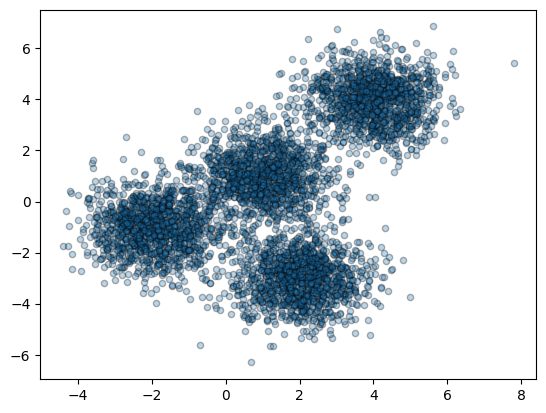

In [14]:
plt.scatter(X[:, 0], X[:, 1], marker='.',alpha=0.3,ec='k',s=80)
# plt.scatter(X축 데이터 (X의 첫 번째 열), Y축 데이터 (X의 두 번째 열), Y축 데이터 (X의 두 번째 열),투명도 (30% 불투명),ec='k',s=80)

각 파라미터 설명:
plt.scatter()는 matplotlib의 산점도(scatter plot)를 그리는 함수로, 2차원 데이터의 분포를 시각화하는 데 사용



+
<h2 id="setting_up_K_means">Setting up k-means</h2>
Now that we have our random data, let's set up our k-means Clustering.


The KMeans class has many parameters that can be used, but we will be using these three:

- `init`: Initialization method of the centroids.
  - Value will be: `k-means++` 
  - `k-means++`: Selects initial cluster centres for k-means clustering in a smart way to speed up convergence.
- `n_clusters`: The number of clusters to form as well as the number of centroids to generate. 
  -  Value will be: 4 (since we have 4 centres) 
- `n_init`: Number of times the k-means algorithm will be run with different centroid seeds. The final results will be the best output of n_init consecutive runs in terms of inertia. 
   - Value will be: 12  


Initialize `KMeans` with these parameters, where the output variable is called `k_means`.


KMeans 클래스에는 사용할 수 있는 매개변수가 많지만, 여기서는 다음 세 가지를 사용합니다.

init: 중심점 초기화 메서드.
값: k-means++
k-means++: k-means 클러스터링의 초기 클러스터 중심점을 지능적인 방식으로 선택하여 수렴 속도를 높입니다.
n_clusters: 생성할 클러스터 수와 중심점 수입니다.
값: 4(중심점이 4개이므로)
n_init: k-means 알고리즘을 서로 다른 중심 시드로 실행할 횟수입니다. 최종 결과는 관성 측면에서 n_init번 연속 실행했을 때 가장 좋은 출력입니다.
값: 12
다음 매개변수로 KMeans를 초기화합니다. 여기서 출력 변수는 k_means입니다.


In [15]:
k_means = KMeans(init = "k-means++", n_clusters = 4, n_init = 12)

# init"k-means++"초기 중심점 설정 방법
# n_clusters4클러스터 개수 (4개 그룹으로 분류)
# n_init12알고리즘 실행 횟수 (12번 중 최고 결과 선택)

Now let's fit the `KMeans` model with the feature matrix we created above, <b> X </b>.


In [16]:
k_means.fit(X)

KMeans(n_clusters=4, n_init=12)

Now let's get the label for each point in the model using the `k_means.labels_` attribute and save them as `k_means_labels`.


In [18]:
k_means_labels = k_means.labels_
k_means_labels
print(k_means_labels)

[0 0 3 ... 3 2 2]


We will also get the coordinates of the cluster centers using `k_means.cluster_centers_` and save it as `k_means_cluster_centers`.


In [19]:
k_means_cluster_centers = k_means.cluster_centers_ #K-Means 학습 후 각 클러스터의 중심점 좌표를 담은 배열
k_means_cluster_centers

array([[-1.95489462, -1.03564706],
       [ 2.00811148, -3.01440138],
       [ 3.99211079,  3.99540917],
       [ 1.01557176,  1.03442098]])

<h2 id="creating_visual_plot">Creating the Visual Plot</h2>

Now that we have the random data generated and the k-means model initialized, let's plot the result and see what it looks like!


Please read through the code and comments to understand how to plot the model.


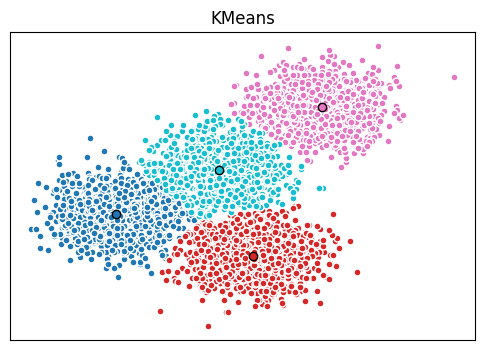

In [25]:
# Initialize the plot with the specified dimensions.
# 지정된 차원으로 플롯을 초기화합니다.
fig = plt.figure(figsize=(6, 4)) #: 그림을 그릴 캔버스를 생성 6인치, 세로 4인치 크기

# Colors uses a color map, which will produce an array of colors based on
# 색상은 색상 맵을 사용하여 색상 배열을 생성합니다.
# the number of labels there are. We use set(k_means_labels) to get the
# 레이블의 개수입니다. set(k_means_labels)를 사용하여 다음을 얻습니다.
# unique labels.
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means_labels)))) #클러스터마다 다른 색상 준비

# Create a plot
ax = fig.add_subplot(1, 1, 1) # (1, 1, 1): 1행 1열의 첫 번째 위치


for k, col in zip(range(len([[4, 4], [-2, -1], [2, -3], [1, 1]])), colors): #각 클러스터 별로 생성

    # Create a list of all data points, where the data points that are 
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    # 데이터 포인트와 중심점을 표시하는 for 루프입니다.
    # k의 범위는 0~3이며, 이는 각
    # 데이터 포인트가 속할 수 있는 클러스터와 일치합니다.

    my_members = (k_means_labels == k) # 각 클러스터에 속한 데이터 찾기

    # Define the centroid, or cluster center.
    # 중심 또는 클러스터 중심을 정의합니다.
    cluster_center = k_means_cluster_centers[k] #클러스터 중심점 가져오기

    # Plots the datapoints with color col.
    # 색상 col을 사용하여 데이터 포인트를 표시합니다.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10) # 데이터 포인트 그리기

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6) #클러스터 중심점 그리기

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()


### Exercise 1
Try to cluster the above dataset into a different number of clusters, say k=3. Note the difference in the pattern generated.


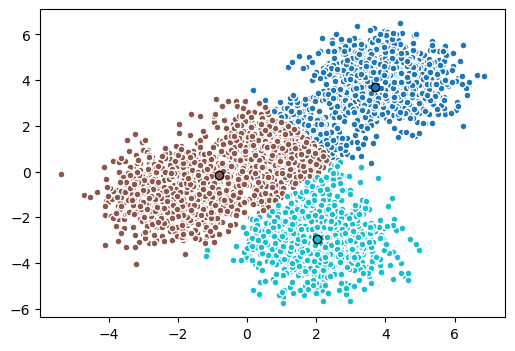

In [11]:
# write your code here
k_means3 = KMeans(init="k-means++", n_clusters=3, n_init=12)
k_means3.fit(X)
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means3.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means3.cluster_centers_)), colors):
    my_members = (k_means3.labels_ == k)
    cluster_center = k_means3.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
plt.show()

<details><summary>Click here for the solution</summary>

```python
k_means3 = KMeans(init="k-means++", n_clusters=3, n_init=12)
k_means3.fit(X)
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means3.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means3.cluster_centers_)), colors):
    my_members = (k_means3.labels_ == k)
    cluster_center = k_means3.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
plt.show()

```

</details>


### Exercise 2
Try the same with k=5.


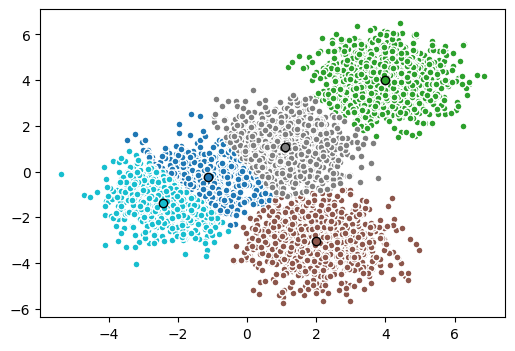

In [12]:
# your code here
k_means3 = KMeans(init="k-means++", n_clusters=5, n_init=12)
k_means3.fit(X)
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means3.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means3.cluster_centers_)), colors):
    my_members = (k_means3.labels_ == k)
    cluster_center = k_means3.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
plt.show()

<details><summary>Click here for the solution</summary>

```python
k_means3 = KMeans(init="k-means++", n_clusters=5, n_init=12)
k_means3.fit(X)
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means3.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means3.cluster_centers_)), colors):
    my_members = (k_means3.labels_ == k)
    cluster_center = k_means3.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
plt.show()

```

</details>


### Exercise 3
Comment on the within-cluster sum of squares, i.e. inertia, of the clusters created for k=3 and k=5. 

### 연습문제 3
k=3과 k=5로 생성된 클러스터의 클러스터 내 제곱합, 즉 관성에 대해 설명하세요.

<details><summary>Click here for the solution</summary>
For k=3, the value of within-cluster sum of squares will be higher that that for k=4, since the points from different natural clusters are being grouped together, leading to underfitting of the k-means model. For k=5, the value of will be lesser than that for k=4, since the points are distributed into mode clusters than needed, leading to over-fitting of the k-means model.
</details>

%% md
<details><summary>해결책을 보려면 여기를 클릭하세요</summary>
k=3의 경우, 서로 다른 자연 클러스터의 점들이 함께 그룹화되어 k-평균 모델이 과소적합되기 때문에 클러스터 내 제곱합의 값이 k=4보다 높습니다. k=5의 경우, 점들이 필요 이상으로 모드 클러스터에 분포되어 k-평균 모델이 과대적합되기 때문에 k=4보다 값이 작습니다.
</details>

<h1 id="customer_segmentation_K_means">Customer Segmentation with k-means</h1>

Imagine that you have a customer dataset, and you need to apply customer segmentation to this historical data.
Customer segmentation is the practice of partitioning a customer base into groups of individuals that have similar characteristics. It is a significant strategy as a business can target these specific groups of customers and effectively allocate marketing resources. For example, one group might contain customers who are high-profit and low-risk, or more likely to purchase products, or subscribe to a service. A business task is to retain those customers.

k-평균을 활용한 고객 세분화¶
고객 데이터 세트가 있고, 이 과거 데이터에 고객 세분화를 적용해야 한다고 가정해 보겠습니다. 고객 세분화는 고객 기반을 유사한 특성을 가진 그룹으로 나누는 과정입니다. 기업이 이러한 특정 고객 그룹을 타겟팅하고 마케팅 자원을 효과적으로 배분할 수 있다는 점에서 중요한 전략입니다. 예를 들어, 한 그룹에는 수익성이 높고 위험도가 낮거나, 제품 구매 또는 서비스 가입 가능성이 높은 고객이 포함될 수 있습니다. 기업의 과제는 이러한 고객을 유지하는 것입니다.


### Load data from CSV file  
Let's use pandas to read the dataset from the cloud storage.


In [27]:
cust_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv")
cust_df

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2
...,...,...,...,...,...,...,...,...,...,...
845,846,27,1,5,26,0.548,1.220,NaN,NBA007,6.8
846,847,28,2,7,34,0.359,2.021,0.0,NBA002,7.0
847,848,25,4,0,18,2.802,3.210,1.0,NBA001,33.4
848,849,32,1,12,28,0.116,0.696,0.0,NBA012,2.9


<h2 id="pre_processing">Pre-processing</h2


As you can see, `Address` in this dataset is a categorical variable. The k-means algorithm doesn't work directly with categorical variables because the Euclidean distance function isn't meaningful for them. You could one-hot encode the categorical feature, but for illustration purposes let's run k-means clustering without it.


보시다시피 이 데이터셋의 `Address`는 범주형 변수입니다. k-평균 알고리즘은 유클리드 거리 함수가 범주형 변수에 의미가 없기 때문에 범주형 변수에 직접 적용되지 않습니다. 범주형 변수에 원-핫 인코딩을 적용할 수도 있지만, 설명을 위해 원-핫 인코딩 없이 k-평균 클러스터링을 실행해 보겠습니다.

In [28]:
cust_df = cust_df.drop('Address', axis=1) #컬럼삭제

In [29]:
# Drop NaNs from the dataframe
cust_df = cust_df.dropna() #비어있는 데이터 삭제
cust_df.info() # 데이터 프레임 확인

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      700 non-null    int64  
 1   Age              700 non-null    int64  
 2   Edu              700 non-null    int64  
 3   Years Employed   700 non-null    int64  
 4   Income           700 non-null    int64  
 5   Card Debt        700 non-null    float64
 6   Other Debt       700 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


After dropping NaNs we still have 700 rows out of the original 849. Let's proceed with this smaller data set.


#### Normalizing over the standard deviation
Now let's normalize the dataset. But why do we need normalization in the first place? Normalization is a statistical method that helps mathematical-based algorithms to interpret features with different magnitudes and distributions equally, tranforming the features so they have zero mean and standard deviation of one. We use `StandardScaler()` to normalize, or standardize our dataset.


In [30]:
X = cust_df.values[:,1:] # leaves out `Customer ID` # 데이터프레임을 배열(array)로 변환
Clus_dataSet = StandardScaler().fit_transform(X)

# StandardScaler() : 데이터를 표준화하는 도구
# .fit_transform(X) : X 데이터를 표준화해서 변환

<h2 id="modeling">Modeling</h2>


Let's apply k-means to the data set. 


### Exercise 4
Write the code to cluster the data with k=3. Extract the cluster labels for this clustering process.

### 연습문제 4
k=3으로 데이터를 클러스터링하는 코드를 작성하세요. 이 클러스터링 과정에 대한 클러스터 레이블을 추출하세요.

In [41]:
# your code here.
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(X)
labels = k_means.labels_
print(labels)

[0 1 1 0 2 0 1 1 1 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0 0 1 0 2 0 0 0 1 0
 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1 1 1 0 0 0 0 1 1 1 2 0 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 1 0 1 2 0 1 0 0 0 0 2 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 1 0 1 1 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 2 0 0 0 1 0 1
 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 2 0 0 0 0 0 1 0 0 0
 2 0 0 0 1 0 2 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0
 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 2 0 0 0 0 0 1 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 

<details><summary>Click here for the solution</summary>

```python
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(X)
labels = k_means.labels_
```

</details>


<h2 id="insights">Insights</h2>
We assign the k-means cluster labels to each row in the dataframe.

<h2 id="insights">인사이트</h2>
데이터프레임의 각 행에 k-평균 클러스터 레이블을 할당합니다.


In [19]:
cust_df["Clus_km"] = labels

We can easily check the centroid values by averaging the features in each cluster. These values indicate the central point of the cluster from the vantage point of the field in question.


각 클러스터의 특징값을 평균화하면 중심값을 쉽게 확인할 수 있습니다. 이 값은 해당 필드의 관점에서 클러스터의 중심점을 나타냅니다.


In [20]:
cust_df.groupby('Clus_km').mean() #데이터프레임에 'Clus_km'이라는 새 컬럼(열) 만들기

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Clus_km,,,,,,,,,
0,439.80226,32.775895,1.632768,6.169492,30.642185,1.003795,2.090910,0.284369,10.146893
1,374.00000,44.785714,3.000000,17.857143,219.714286,6.115429,11.546357,0.285714,8.064286
2,403.56129,41.103226,1.916129,15.135484,81.122581,3.024935,5.605258,0.180645,10.848387


Now, let's look at the distribution of customers based on their education, age and income. We can choose to visualise this as a 2D scatter plot with Age on the x-axis, Income on the y-axis and the marker size representing education. The scatter points will be assigned different colors based on different class labels.


이제 교육, 연령, 소득에 따른 고객 분포를 살펴보겠습니다. x축에 연령, y축에 소득, 그리고 교육 수준을 나타내는 마커 크기를 갖는 2D 산점도로 시각화할 수 있습니다. 산점도는 계층 레이블에 따라 다른 색상으로 표시됩니다.

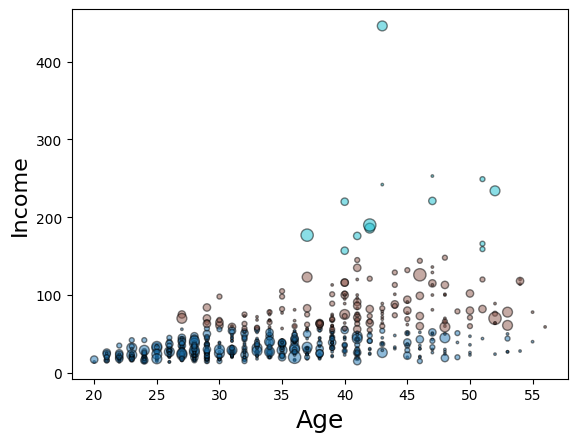

In [43]:
area = np.pi * ( X[:, 1])**2  
plt.scatter(X[:, 0], X[:, 3], s=area, c=labels.astype(float), cmap='tab10', ec='k',alpha=0.5)

#area: 그래프에 표시될 원(점)의 크기
#X[:, 1]: X 배열에서 1번 인덱스 컬럼 전체 (아마 교육년수 같은 값)
#**2: 제곱 (2승)
#np.pi: 원주율 파이(π ≈ 3.14)
#전체 의미: 원의 넓이 공식 (π × 반지름²)을 사용해서 원 크기 계산

#왜 이렇게 하나요?
#→ 특정 값이 클수록 그래프에서 원이 크게 표시되도록!

plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)
plt.show()

We can also see this distribution in 3 dimensions for better understanding. Here, the education parameter will represent the third axis instead of the marker size. 


더 나은 이해를 위해 이 분포를 3차원에서도 볼 수 있습니다. 여기서는 마커 크기 대신 교육 매개변수가 세 번째 축을 나타냅니다.

In [46]:
# Create interactive 3D scatter plot
#**`px.scatter_3d()`**: 3D 산점도를 그리는 함수 (plotly 라이브러리)
#- **`X`**: 데이터
#- **`x=1`**: x축에 1번 인덱스 컬럼 (교육)
#- **`y=0`**: y축에 0번 인덱스 컬럼 (나이)
#- **`z=3`**: z축에 3번 인덱스 컬럼 (수입)
#- **`opacity=0.7`**: 투명도 70% (점들이 겹쳐도 보임)
#- **`color=labels`**: 그룹별로 색깔 다르게
fig = px.scatter_3d(X, x=1, y=0, z=3, opacity=0.6, color=labels.astype(float))


#fig.update_traces(): 그래프의 점 스타일 업데이트
#marker=dict(...): 점(마커) 설정
#size=5: 점 크기 5
#line=dict(width=.25): 점 테두리 두께 0.25
#showlegend=False: 범례(색상 설명) 숨김
fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=False) #그래프 전체 레이아웃 설정

#coloraxis_showscale=False: 색상 막대 숨김 (옆에 나오는 그라데이션 바)
#width=1000, height=800: 그래프 크기 (가로 1000px, 세로 800px)
#scene=dict(...): 3D 공간 설정
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene=dict(
        xaxis=dict(title='Education'),
        yaxis=dict(title='Age'),
        zaxis=dict(title='Income')
    ))  # Remove color bar, resize plot

fig.show()





#z축(수입) ↑
#               |  ●(빨강)
#               | /
#               |/  ●(파랑)
#     y축(나이)←+————————→ x축(교육)
#             /|
#            / |




#fig.update_layout(): 그래프 전체 레이아웃 설정
#coloraxis_showscale=False: 색상 막대 숨김 (옆에 나오는 그라데이션 바)
#width=1000, height=800: 그래프 크기 (가로 1000px, 세로 800px)
#scene=dict(...): 3D 공간 설정

#xaxis=dict(title='Education'): x축 이름 'Education'
#yaxis=dict(title='Age'): y축 이름 'Age'
#zaxis=dict(title='Income'): z축 이름 'Income'

k-means will partition your customers into mutually exclusive groups, for example, into 3 clusters. The customers in each cluster are similar to each other demographically.

### Exercise 5
Create a profile for each group, considering the common characteristics of each cluster based on your observations. 


k-평균은 고객을 상호 배타적인 그룹, 예를 들어 3개의 클러스터로 분할합니다. 각 클러스터의 고객은 인구통계학적으로 서로 유사합니다.

### 연습 5
관찰 결과를 바탕으로 각 클러스터의 공통적인 특성을 고려하여 각 그룹에 대한 프로필을 작성하세요.

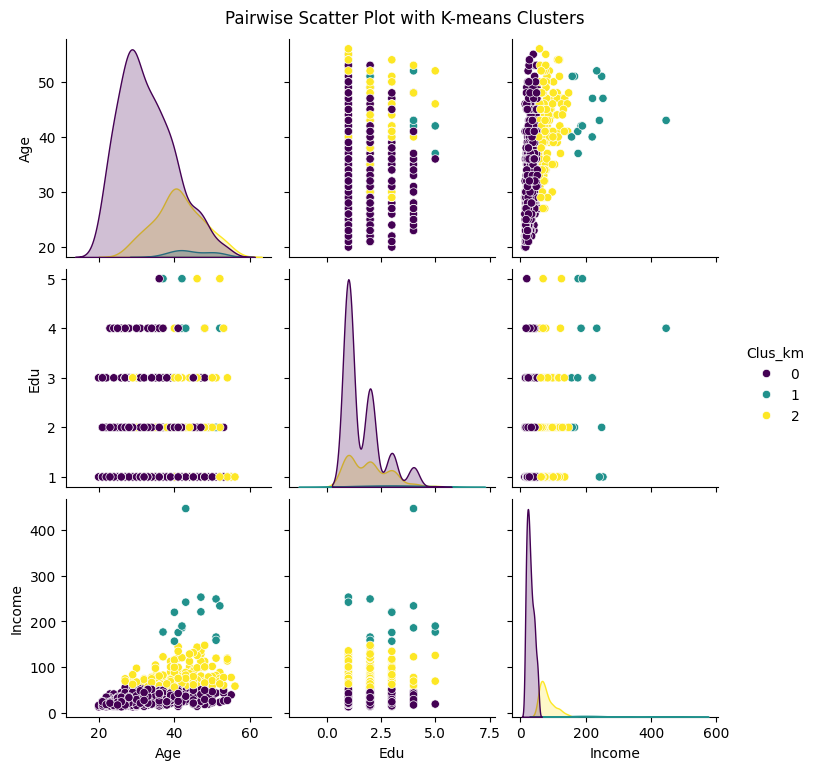

In [23]:
cust_df_sub = cust_df[['Age', 'Edu','Income','Clus_km']].copy()  #cust_df[['Age', 'Edu','Income','Clus_km']]: 원본 데이터에서 4개 컬럼만 선택 cust_df[['Age', 'Edu','Income','Clus_km']]: 원본 데이터에서 4개 컬럼만 선택
sns.pairplot(cust_df_sub, hue='Clus_km', palette='viridis', diag_kind='kde') 
plt.suptitle('Pairwise Scatter Plot with K-means Clusters', y=1.02)
plt.show()

#Enter your Obserrvation


<details><summary>Click here for the solution</summary>
The 3 clusters can be:

- LATE CAREER, AFFLUENT, AND EDUCATED
- MID CAREER AND MIDDLE INCOME
- EARLY CAREER AND LOW INCOME

</details>


### Congratulations! You're ready to move on to your next lesson!

## Author
<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>

### Other Contributors
<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>  
 
<h3 align="center"> © IBM Corporation. All rights reserved. <h3/>

 
<!--
## Change Log
 
 
|  Date (YYYY-MM-DD) |  Version       | Changed By     | Change Description                  |
|---|---|---|---|
| 2024-10-31         | 3.0            | Jeff Grossman  | Rewrite                             |
| 2020-11-03         | 2.1            | Lakshmi        | Made changes in URL                 |
| 2020-11-03         | 2.1            | Lakshmi        | Made changes in URL                 |
| 2020-08-27         | 2.0            | Lavanya        | Moved lab to course repo in GitLab  |
|   |   |   |   |
